In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Welcome Sir\Downloads\Projects\Superstore Sales Dataset.csv")

print(df.info()) #Missing values and data types check
print ('Missing values info above')
print ('')

print(df.duplicated().sum()) #Check for duplicate rows
print ('Duplicate info above')
print ('')

print(df['Sales'].describe()) #Statistical spread of sales
print ('Statistical spread of dales above')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
df['Order Date'].head()

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: object

In [9]:
df['Ship Date'].head()

0    11/11/2017
1    11/11/2017
2    16/06/2017
3    18/10/2016
4    18/10/2016
Name: Ship Date, dtype: object

In [10]:
df['Postal Code'].head()

0    42420.0
1    42420.0
2    90036.0
3    33311.0
4    33311.0
Name: Postal Code, dtype: float64

In [20]:
#Postal code needs to be converted to strings to remove all decimal places and pad with zeros to ensure it's 5 digits.
df['Postal Code'] = df['Postal Code'].astype(str).str.split('.').str[0].str.zfill(5)
print('Successfully converted floats to string and padded with Zeros where necessary.')

Successfully converted floats to string and padded with Zeros where necessary.


In [21]:
df[df['Sales']<0] #Check for Negative sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales


In [28]:
#Data Transformation
#To see seasonality we will create new columns of data which include:
#Order year, month name, Day of the week, and shipping duration i.e shipping date - order date

#Conversion to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst = True)
print("Conversion to 'datetime' done!")
print(" ")

#Extract Order year, month name, day of the week.
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order day'] = df['Order Date'].dt.day_name()
print('Feature Extraction done!!')
print(" ")

#Create and Compute Shipping duration Column
df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
print('Shipping duration column created')

Conversion to 'datetime' done!
 
Feature Extraction done!!
 
Shipping duration column created


In [29]:
#Get statistical data of shipping duration
print(df['Ship Duration'].describe()) #Statistical spread of Ship Duration
print ('Statistical spread of dales above')

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Ship Duration, dtype: float64
Statistical spread of dales above


In [31]:
#Binning and Categorization of sales based on Price points based on the interquartile range
#Calculating Quartiles
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

#Bins based on these stats
bins = [0, Q1, Q3, upper_bound, float('inf')]
labels = ['Low Volume', 'Average', 'High Volume', 'Outlier']
df['Order Value Category'] = pd.cut(df['Sales'], bins=bins, labels=labels)

print(f"Statistical Thresholds:\n Q1: {Q1}\n Q3: {Q3}\n Outlier: {upper_bound}")

Statistical Thresholds:
 Q1: 17.248
 Q3: 210.60500000000002
 Outlier: 500.6405000000001


In [33]:
#Monthly Sales trend by Category
monthly_trend = df.groupby(['Order Year', 'Order Month', 'Category']) ['Sales'].sum().reset_index()
print('Monthly sales trend created')

Monthly sales trend created


In [34]:
df.to_csv(r'C:\Users\Welcome Sir\Downloads\Projects\Superstore Sales Dataset v1.csv')

In [36]:
monthly_trend.to_csv(r'C:\Users\Welcome Sir\Downloads\Projects\monthly_sales_summary.csv', index=False)

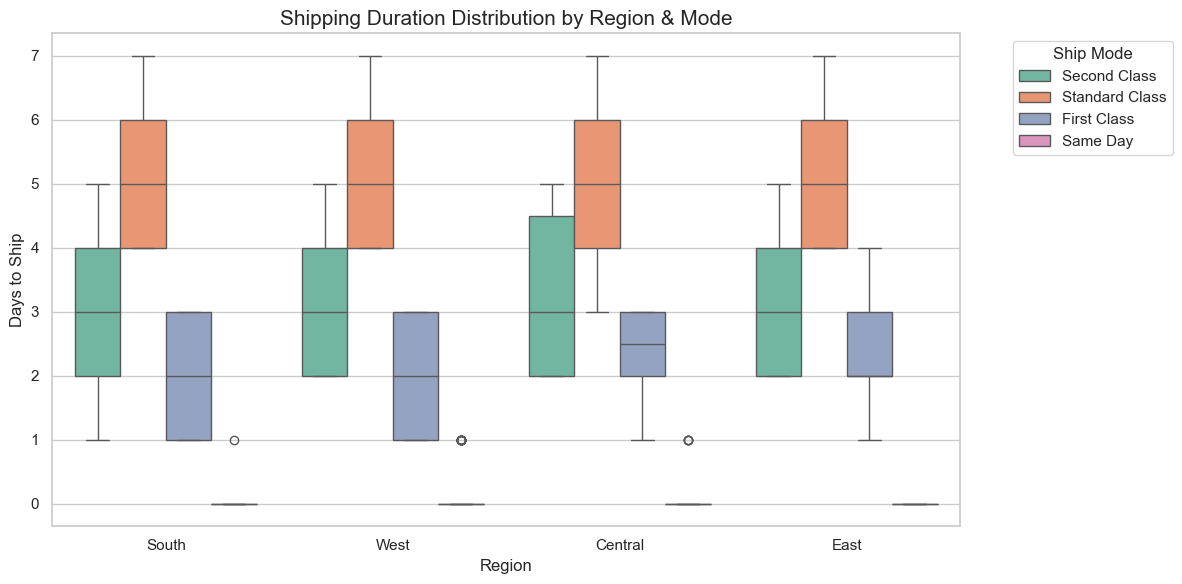

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting a clean style for the report
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Region', y='Ship Duration', hue='Ship Mode', palette='Set2')

plt.title('Shipping Duration Distribution by Region & Mode', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Days to Ship', fontsize=12)
plt.legend(title='Ship Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r'C:\Users\Welcome Sir\Downloads\Projects\Shipping_Duration_Distribution.png')
plt.show()

C:\Users\Welcome Sir\AppData\Local\Temp\ipykernel_26080\1102260511.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_sales = df.groupby('Order Value Category')['Sales'].sum()


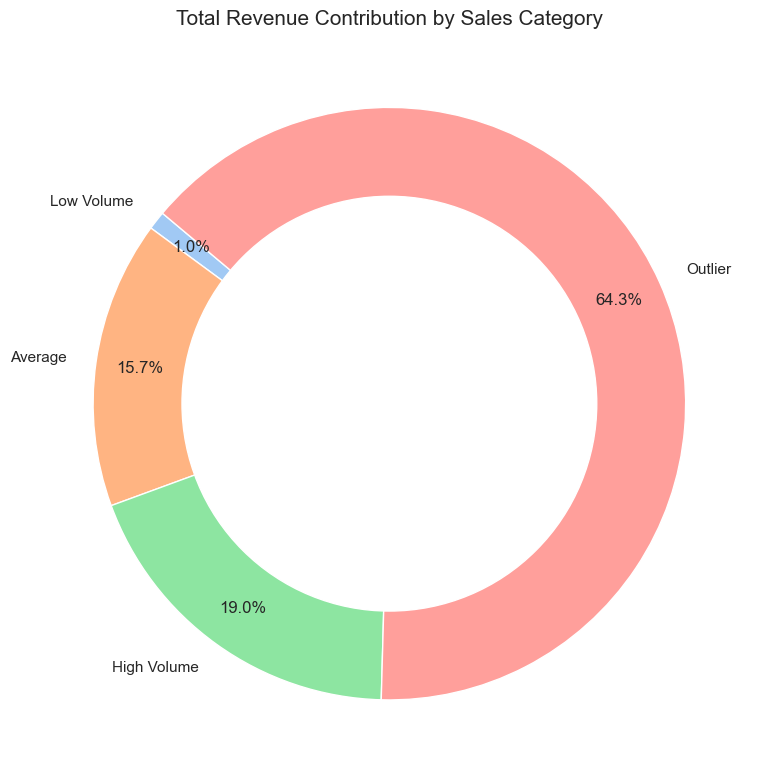

In [47]:
# Aggregate sales by your bins
bin_sales = df.groupby('Order Value Category')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(bin_sales, labels=bin_sales.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'), pctdistance=0.85)

# Drawing a circle in the middle to make it a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Total Revenue Contribution by Sales Category', fontsize=15)
plt.tight_layout()
plt.savefig(r'C:\Users\Welcome Sir\Downloads\Projects\Total_Revenue_Contribution_by_Sales_Category.png')
plt.show()

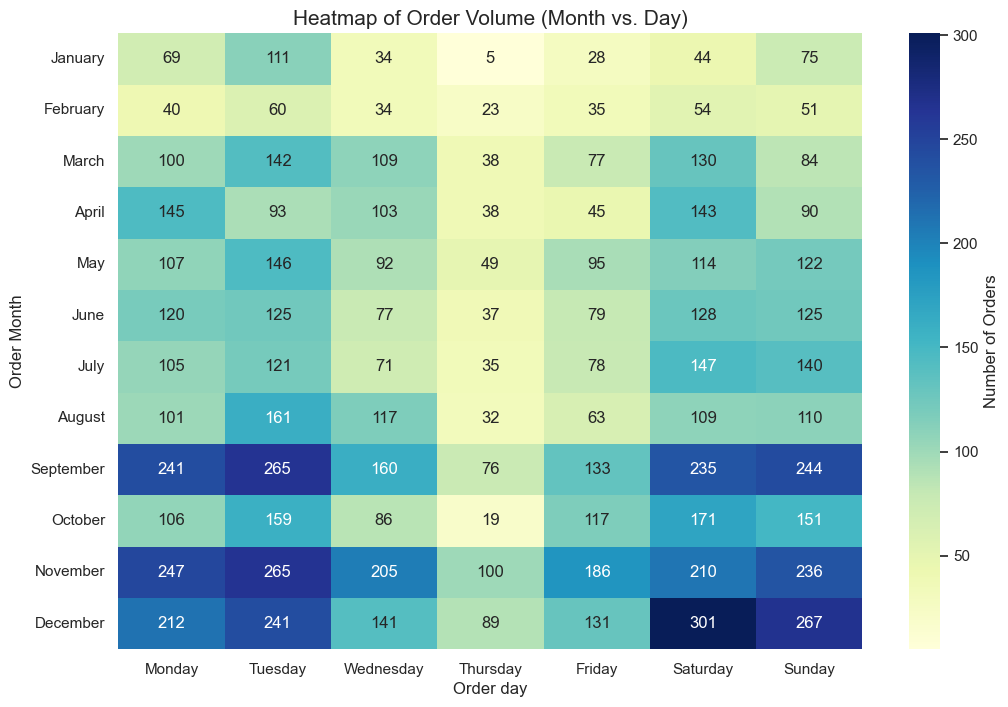

In [48]:
# 1. Create the pivot table (Count of Order IDs)
heatmap_data = df.pivot_table(index='Order Month', 
                             columns='Order day', 
                             values='Order ID', 
                             aggfunc='count')

# 2. Sort months and days correctly
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = heatmap_data.reindex(index=months_order, columns=days_order)

# 3. Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Number of Orders'})
plt.title('Heatmap of Order Volume (Month vs. Day)', fontsize=15)
plt.savefig(r'C:\Users\Welcome Sir\Downloads\Projects\Heatmap_of_Order_Volume.png')
plt.show()

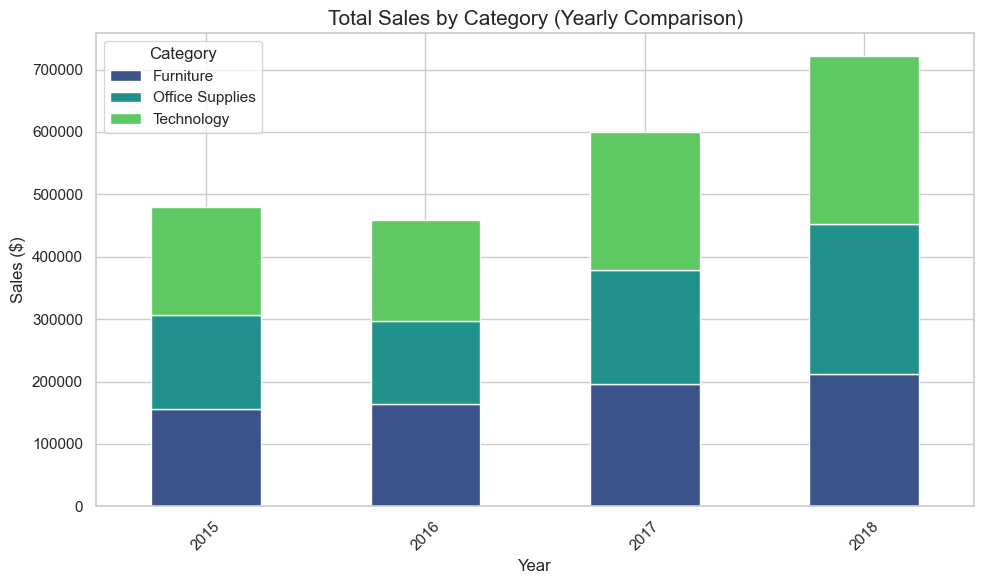

In [49]:
# Aggregate Sales by Year and Category
yearly_cat_sales = df.groupby(['Order Year', 'Category'])['Sales'].sum().unstack()

yearly_cat_sales.plot(kind='bar', stacked=True, figsize=(10, 6), color=sns.color_palette('viridis', 3))

plt.title('Total Sales by Category (Yearly Comparison)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig(r'C:\Users\Welcome Sir\Downloads\Projects\Total_Sales_by_Category.png')
plt.show()